1. Binning

Binning means converting a continuous numerical feature into intervals (bins).
Instead of using the exact value, we use the bin/category it belongs to.

Example
Suppose we have ages:
[12, 18, 25, 35, 45, 60]

Create bins:
    
Age Range	 Category
0–18	      Child
19–35	   Young Adult
36–50	       Adult
51+	          Senior

After binning:

12 → Child
18 → Child
25 → Young Adult
35 → Young Adult
45 → Adult
60 → Senior

Why use binning?

Reduces noise in data
Makes patterns easier for some models
Converts continuous data into categorical data

Types of Binning

1. Equal Width Binning

Divide the range into equal-sized intervals.

Example:
Marks: 0–100
Bin1: 0–25
Bin2: 25–50
Bin3: 50–75
Bin4: 75–100

2. Equal Frequency Binning

Each bin contains approximately the same number of samples.
    
Example:
Values: [1,2,3,4,5,6,7,8]
Bin1: [1,2,3,4]
Bin2: [5,6,7,8]
Each bin has 4 values.

3. K-Mean Binning
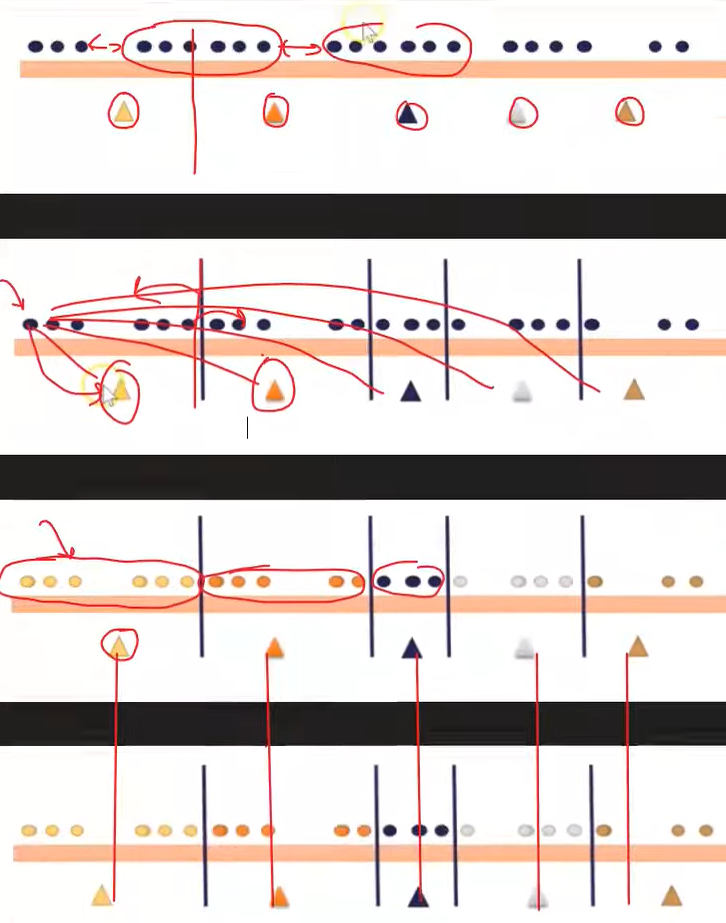


In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [12]:
clf = DecisionTreeClassifier()

In [13]:
clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
y_pred = clf.predict(X_test)

In [15]:
accuracy_score(y_test,y_pred)

0.6223776223776224

In [16]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6261345852895148)

In [44]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [45]:
trf = ColumnTransformer([('trf1',kbin_age,[0]),('trf2',kbin_fare,[1])])

In [46]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

C:\Users\yango\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\yango\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [47]:
X_train_transformed

array([[ 8.,  8.],
       [ 6.,  7.],
       [ 8.,  7.],
       ...,
       [11., 14.],
       [ 9.,  8.],
       [ 9.,  3.]], shape=(571, 2))

In [48]:
trf.named_transformers_

{'trf1': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'trf2': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [49]:
trf.named_transformers_['trf1'].n_bins_

array([15])

In [50]:
trf.named_transformers_['trf1'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [51]:
output = pd.DataFrame({'age':X_train['Age'],'age_trf':X_train_transformed[:,0],'fare':X_train['Fare'],'fare_trf':X_train_transformed[:,1]})

In [52]:
output.sample(5)

,age,age_trf,fare,fare_trf
106,21.0,4.0,7.650,1.0
173,21.0,4.0,7.925,3.0
801,31.0,8.0,26.250,9.0
520,30.0,8.0,93.500,13.0
230,35.0,10.0,83.475,13.0


In [53]:
output['age_labels'] = pd.cut(x=X_train['Age'],bins=trf.named_transformers_['trf1'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],bins=trf.named_transformers_['trf2'].bin_edges_[0].tolist())

In [54]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
321,27.0,6.0,7.8958,3.0,"(25.0, 28.0]","(7.775, 7.896]"
503,37.0,10.0,9.5875,4.0,"(35.0, 38.0]","(8.158, 10.5]"
482,50.0,13.0,8.0500,3.0,"(47.0, 54.0]","(7.896, 8.158]"
587,60.0,14.0,79.2000,13.0,"(54.0, 80.0]","(76.292, 108.9]"
174,56.0,14.0,30.6958,10.0,"(54.0, 80.0]","(26.55, 31.275]"


In [55]:
clf.fit(X_train_transformed,y_train)
y_pred2 = clf.predict(X_test_transformed)

In [56]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [57]:
X_transformed = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_transformed,y,cv=10,scoring='accuracy'))

C:\Users\yango\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\yango\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.6723004694835681)

Custom (Domain-Based) Binning

Custom binning means creating bins using domain knowledge (knowledge about the problem) instead of using automatic methods like equal-width, equal-frequency, or K-Means.

The bin ranges are decided by a human who understands the data.

Example 1: Age

Suppose you have ages:

[12, 18, 25, 40, 65]

Using domain knowledge, you might define:

Age Range	Category
0–12	Child
13–19	Teen
20–59	Adult
60+	Senior